# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [5]:
df=pd.read_csv('base_logistica_entregas.csv')
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim


# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [6]:
#1
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [7]:
#2
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [8]:
#3, 4
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    str    
 6   clima              200 non-null    str    
 7   tipo_entrega       200 non-null    str    
 8   regiao             200 non-null    str    
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 17.3 KB


,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [9]:
#5
df.isnull().sum()

id_pedido            0
distancia_km         0
peso_kg              0
qtd_itens            0
valor_pedido         0
trafego              0
clima                0
tipo_entrega         0
regiao               0
tempo_entrega_min    0
atrasou              0
dtype: int64

In [10]:
#6
df.shape

(200, 11)

In [11]:
# regressão alvo = tempo_entrega_min

In [12]:
#distancia_km, peso_kg, qtd_itens, valor_pedido, trafego, clima, tipo_entrega, regiao

In [13]:
#trafego, clima, tipo_entrega, regiao, atrasou

In [14]:
#Não podemos usar variáveis categóricas diretamente na regressão linear porque o modelo trabalha com números

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [15]:
df['tempo_entrega_min'].mean()


np.float64(158.355)

In [16]:
np.median(df['tempo_entrega_min'])

np.float64(158.5)

In [17]:
df['tempo_entrega_min'].std()

np.float64(49.450436838491)

In [18]:
df['tempo_entrega_min'].min(), df['tempo_entrega_min'].max()

(np.int64(44), np.int64(286))

In [19]:
df['tempo_entrega_min'].quantile([0.25,0.5,0.75])

0.25    126.00
0.50    158.50
0.75    189.25
Name: tempo_entrega_min, dtype: float64

In [20]:
#Se a média for maior que a mediana, ndica que existem valores altos puxando a média para cima
#Se a média e a mediana forem próximas, os dados são mais simétricos

In [21]:
#Sim, o desvio padrão é relativamente alto comparado com a média.

In [22]:
Q1 = df["tempo_entrega_min"].quantile(0.25)
Q3 = df["tempo_entrega_min"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[df["tempo_entrega_min"] > Q3 + 1.5 * IQR]
outliers

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
21,22,68.1,29.7,10,1121.44,alto,normal,normal,zona_rural,286,sim


In [23]:
df.groupby('tipo_entrega')['tempo_entrega_min'].mean()

tipo_entrega
expressa    149.894737
normal      161.727273
Name: tempo_entrega_min, dtype: float64

In [24]:
df.groupby('trafego')['tempo_entrega_min'].mean()

trafego
alto     188.075000
baixo    135.119403
medio    162.311828
Name: tempo_entrega_min, dtype: float64

# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

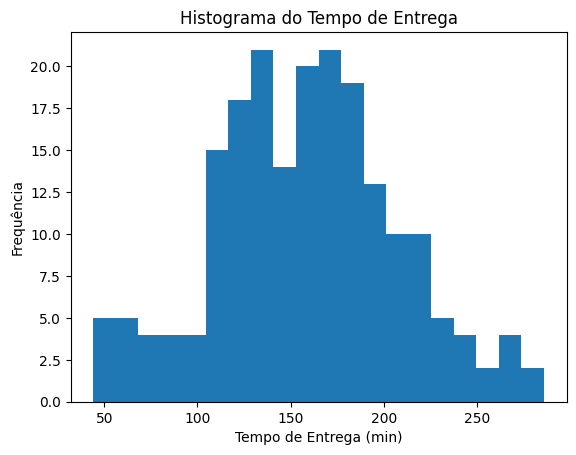

In [25]:
import matplotlib.pyplot as plt

plt.hist(df["tempo_entrega_min"], bins=20)
plt.xlabel("Tempo de Entrega (min)")
plt.ylabel("Frequência")
plt.title("Histograma do Tempo de Entrega")
plt.show()

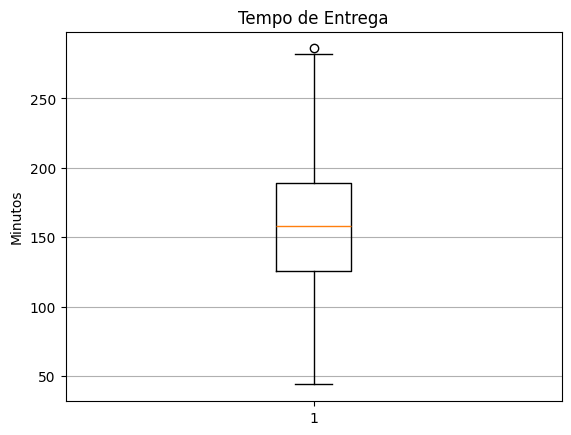

In [26]:
plt.boxplot(df['tempo_entrega_min'])
plt.title('Tempo de Entrega')
plt.ylabel('Minutos')
plt.grid(axis='y')
plt.show()

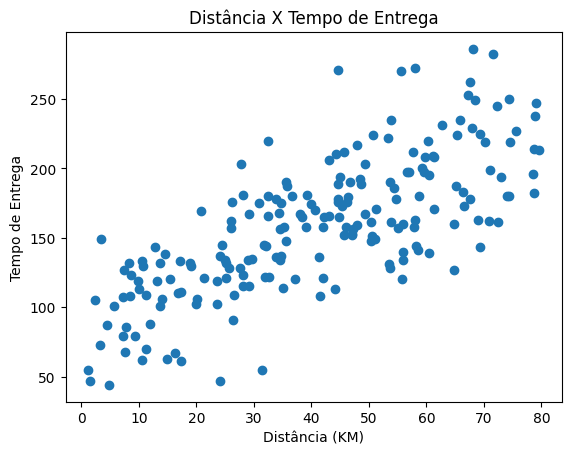

In [27]:
plt.scatter(df['distancia_km'], df['tempo_entrega_min'])
plt.xlabel('Distância (KM)')
plt.ylabel('Tempo de Entrega')
plt.title('Distância X Tempo de Entrega')
plt.show()

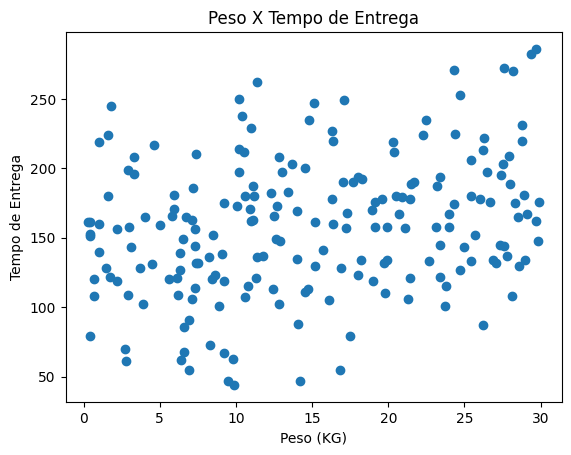

In [28]:
plt.scatter(df['peso_kg'],df['tempo_entrega_min'])
plt.xlabel('Peso (KG)')
plt.ylabel('Tempo de Entrega')
plt.title('Peso X Tempo de Entrega')
plt.show()

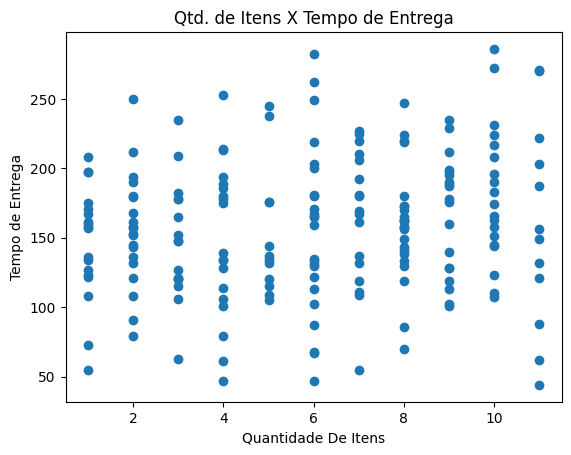

In [29]:
plt.scatter(df['qtd_itens'], df['tempo_entrega_min'])
plt.xlabel('Quantidade De Itens')
plt.ylabel('Tempo de Entrega')
plt.title('Qtd. de Itens X Tempo de Entrega')
plt.show()

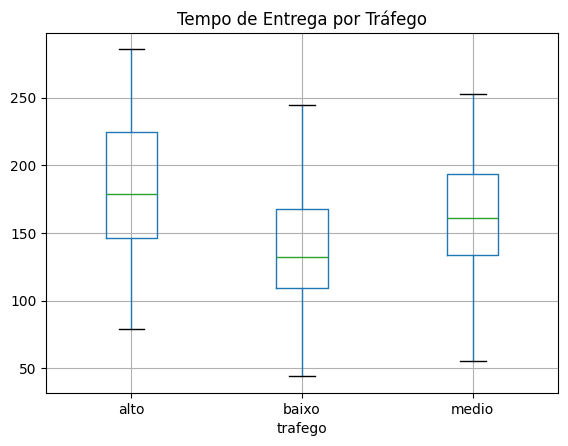

In [30]:
df.boxplot(column='tempo_entrega_min', by='trafego')
plt.title('Tempo de Entrega por Tráfego')
plt.suptitle('')
plt.show()

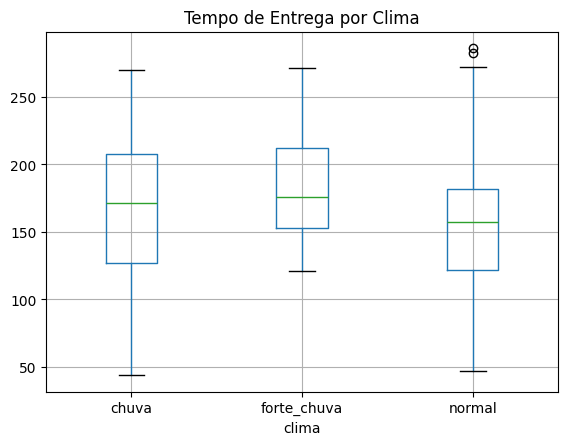

In [31]:
df.boxplot(column='tempo_entrega_min', by='clima')
plt.title('Tempo de Entrega por Clima')
plt.suptitle('')
plt.show()

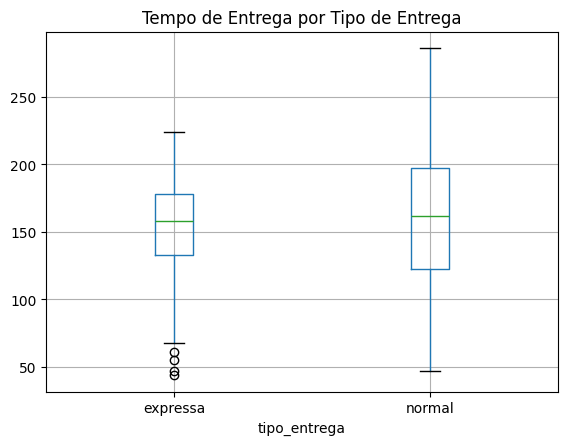

In [32]:
df.boxplot(column='tempo_entrega_min', by='tipo_entrega')
plt.title('Tempo de Entrega por Tipo de Entrega')
plt.suptitle('')
plt.show()

In [33]:
#Distância

In [34]:
#Sim, se a distância aumenta, o tempo de entrega também aumenta

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [35]:
df_num=df.select_dtypes(include={'int64','float64'})
df_num

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,1,56.0,16.4,9,2158.92,160
1,2,23.6,2.2,9,1431.91,119
2,3,18.9,19.7,5,464.30,132
3,4,44.6,29.9,5,1290.63,176
4,5,57.8,23.1,1,1899.66,158
...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,171
196,197,3.5,6.5,11,1356.59,149
197,198,59.8,12.8,10,2247.45,208
198,199,38.4,6.7,3,2369.26,165


In [36]:
corr=df_num.corr()
corr

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
id_pedido,1.000000,-0.010864,0.020593,-0.034910,0.036968,0.014440
distancia_km,-0.010864,1.000000,-0.020853,-0.039094,-0.073556,0.743120
peso_kg,0.020593,-0.020853,1.000000,0.016054,-0.037019,0.280642
qtd_itens,-0.034910,-0.039094,0.016054,1.000000,0.132516,0.156666
valor_pedido,0.036968,-0.073556,-0.037019,0.132516,1.000000,-0.045193
tempo_entrega_min,0.014440,0.743120,0.280642,0.156666,-0.045193,1.000000


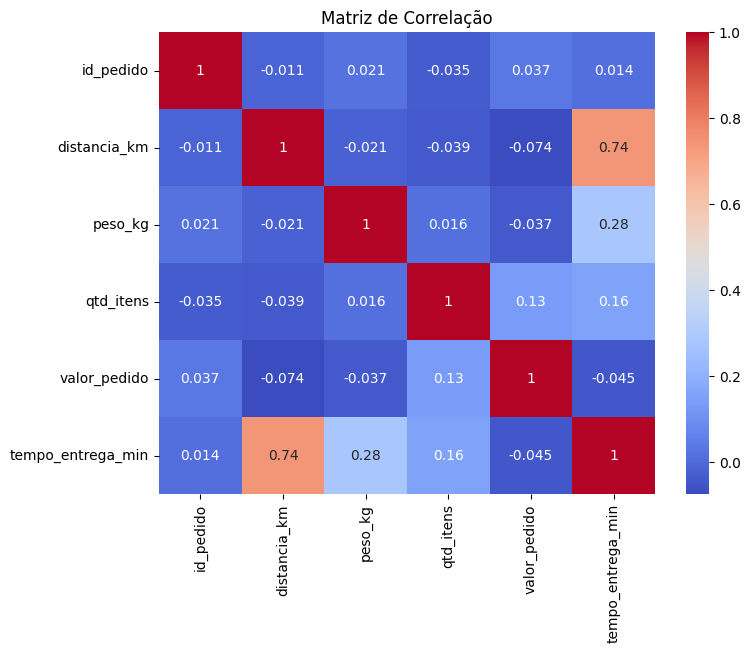

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [38]:
#distancia_km

In [39]:
#valor_pedido

In [40]:
#Correlação não implica casualidade

In [41]:
#Não necessariamente, ainda pode ser útil com outras variáveis.

In [42]:
#Sim, apresenta alta correlação com o tempo de entrega

In [43]:
#Peso parece ter pouca influência no tempo de entrega, sendo mais fraco do que a correlação entre tempo e distância.

In [44]:
#distancia_km, qtd_itens, tempo_entrega_min

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [45]:
X=df[['distancia_km']]
y=df['tempo_entrega_min']

modelo=LinearRegression()
modelo.fit(X,y)

modelo.coef_[0]

np.float64(1.746043224140507)

In [46]:
modelo.intercept_

np.float64(87.19064329209327)

In [47]:
#O coeficiente indica o quanto o tempo de entrega aumenta para cada km adicional

In [48]:
y_pred=modelo.predict(X)

In [49]:
resultado= pd.DataFrame({
    'tempo_real':y,
    'tempo_previsto':y_pred,
    'erro':y-y_pred
})

resultado.head(10)

,tempo_real,tempo_previsto,erro
0,160,184.969064,-24.969064
1,119,128.397263,-9.397263
2,132,120.190860,11.809140
3,176,165.064171,10.935829
4,158,188.111942,-30.111942
5,168,147.254530,20.745470
6,196,224.255036,-28.255036
7,157,183.397625,-26.397625
8,158,155.286329,2.713671
9,122,143.064026,-21.064026


In [50]:
mae=mean_absolute_error(y,y_pred)
rmse=np.sqrt(mean_squared_error(y,y_pred))
r2=r2_score(y,y_pred)

mae, rmse, r2

(26.2844220296317, np.float64(33.00733909155887), 0.5522272255900884)

In [51]:
#mae é o erro médio absoluto das previsões

#rmse penaliza erros maiores, indicando magnitude

#r2 mostra o quanto o modelo consegue explicar a variação de dados, mais próximo de 1, melhor

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

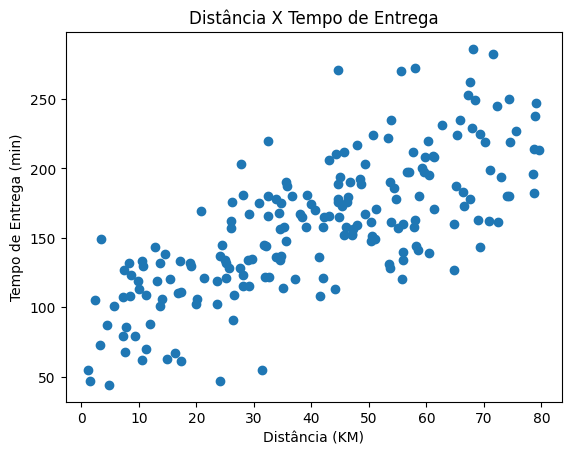

In [52]:
plt.scatter(df['distancia_km'], df['tempo_entrega_min'])
plt.xlabel('Distância (KM)')
plt.ylabel('Tempo de Entrega (min)')
plt.title('Distância X Tempo de Entrega')
plt.show()

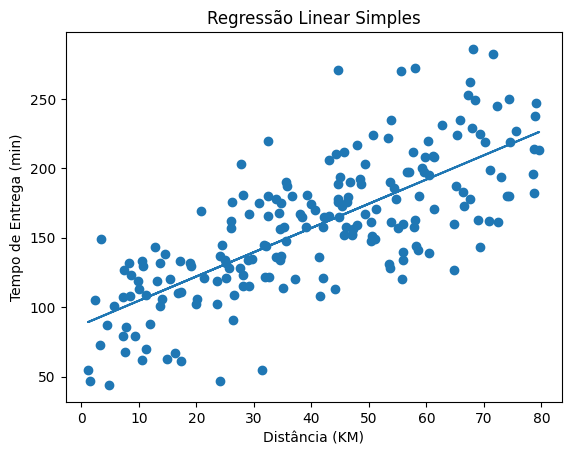

In [53]:
plt.scatter(df['distancia_km'], df['tempo_entrega_min'])

plt.plot(df['distancia_km'], y_pred)

plt.xlabel('Distância (KM)')
plt.ylabel('Tempo de Entrega (min)')
plt.title('Regressão Linear Simples')
plt.show()

In [54]:
#Parcialmente, existe uma clara correlação de tempo & distância, mas outros fatores influenciam o tempo, dispersando os pontos.

In [55]:
#Sim

In [56]:
#Representam situações atípicas, clima intensos, erros operacionais, atrasos etc.

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [57]:
#Deu um tipo de warning, então fiz desse jeito

In [58]:
modelo.predict(pd.DataFrame({"distancia_km": [5]}))

array([95.92085941])

In [59]:
modelo.predict(pd.DataFrame({"distancia_km": [20]}))

array([122.11150777])

In [60]:
modelo.predict(pd.DataFrame({"distancia_km": [60]}))

array([191.95323674])

In [61]:
#Parcialmente, considerando apenas a distância, ele pode gerar estimativas imprecisas na realidade já que outros fatores influenciam no tempo

In [62]:

#Clima, Tráfego, Qtd. Itens, Peso, Tipo de entrega, Região

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [63]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [64]:
#O get_dummies transformou as variáveis categóricas em variáveis numéricas binárias, com valores 1 (True) e 0 (False)


In [65]:
#o drop_first=True serve para evitar o "dummy trap" (multicolinearidade), manter todas as colunas pode prejudicar o modelo de regressão

In [66]:
#trafego_baixo, trafego_medio
#clima_forte_chuva, clima_normal
#regiao_centro, regiao_zona_rural
#tipo_entrega_normal

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [67]:
X=df_modelo.drop(['id_pedido', 'tempo_entrega_min', 'atrasou'], axis=1)

In [68]:
y=df_modelo['tempo_entrega_min']

In [69]:
modelo_multi=LinearRegression()
modelo_multi.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
y_pred_multi=modelo_multi.predict(X)

In [71]:
mae_multi=mean_absolute_error(y,y_pred_multi)
mae_multi

14.47981830172203

In [72]:
rmse_multi=np.sqrt(mean_squared_error(y,y_pred_multi))
rmse_multi

np.float64(17.584048754061453)

In [73]:
r2_multi=r2_score(y,y_pred_multi)
r2_multi

0.872920817369726

In [74]:
#O modelo múltiplo apresenta mais desempenho que o simples pois utiliza mais variáveis explicativas, tornando-se mais complexa.

In [75]:
#Sim, pode ser observado pela redução de erros e pelo aumento do R2

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [76]:
coeficientes = pd.DataFrame({
    "variavel":X.columns,
    "coeficiente":modelo_multi.coef_
})

coeficientes

,variavel,coeficiente
0,distancia_km,1.801969
1,peso_kg,1.443045
2,qtd_itens,2.557247
3,valor_pedido,0.000152
4,trafego_baixo,-35.000253
5,trafego_medio,-17.819863
6,clima_forte_chuva,28.839053
7,clima_normal,-12.477173
8,tipo_entrega_normal,25.284407
9,regiao_centro,-11.643316


In [77]:
coeficientes.sort_values(by="coeficiente", ascending=False)


,variavel,coeficiente
6,clima_forte_chuva,28.839053
8,tipo_entrega_normal,25.284407
10,regiao_zona_rural,14.674497
2,qtd_itens,2.557247
0,distancia_km,1.801969
1,peso_kg,1.443045
3,valor_pedido,0.000152
9,regiao_centro,-11.643316
7,clima_normal,-12.477173
5,trafego_medio,-17.819863


In [78]:
#Positivos

In [79]:
#Negativos

In [80]:
#O coeficiente de distancia_km indica quanto o tempo de entrega aumenta em média para cada quilômetro adicional percorrido.

In [81]:
#Em meu dataset ficou tipo_entrega_normal e a expressa virou a categoria de referência.
#O coeficiente mostra a diferença de tempo em relação à entrega expressa, se for positivo significa que entregas normais demoram mais que expressas.

In [82]:
#Aconteceu a mesma coisa que aconteceu com a entrega expressa com trafego alto.
#Já que o tráfego alto é referência, os coeficientes de trafego_baixo e trafego_medio indicam a diferença em relação ao tráfego alto.
#Coeficientes negativos indicam entregas mais rápidas

In [83]:
#O coeficiente de clima_forte_chuva indica o impacto da forte chuva no tempo de entrega
#Se for positivo, significa que entregas em forte chuva tendem a demorar mais

In [84]:
#Sim, condições favoráveis reduz o tempo enquanto não favoráveis aumentam (chuva forte, tráfego alto, etc)

In [85]:
#Dados inconsistentes, outliers, relação fraca entre variável e alvo, poucos dados, multicolinearidade,

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [86]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


In [87]:
modelo_treino=LinearRegression()
modelo_treino.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
y_pred_test=modelo_treino.predict(X_test)

In [89]:
mae_test= mean_absolute_error(y_test, y_pred_test)
mae_test

16.37904003411503

In [90]:
y_pred_train = modelo_treino.predict(X_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

mae_train, rmse_train, r2_train

(13.84025387255215, np.float64(16.850233318242896), 0.8844577390406828)

In [91]:
rmse_test=np.sqrt(mean_squared_error(y_test, y_pred_test))

rmse_test

np.float64(19.874255695823294)

In [92]:
r2_test=r2_score(y_test, y_pred_test)
r2_test

0.8333215635990179

In [93]:
#As métricas estão relativamente próximas, 
# o MAE e RMSE são maiores no teste o que é esperado já que os dados não foram vistos durante o treinamento
# O R2 caiu 0.05, mas permanece alto.

In [94]:
#Sim, o modelo parece generalizar bem.

In [95]:
#Overfitting ocorreria caso o modelo tivesse desempenho extremamente bom no treino, mas desempenho ruim no teste.
#Indicando que o modelo decorou os dados de treino e não consegue generalizar para novos dados

In [96]:
#Validar o modelo com mais dados, verificar presença de outliers, testar em cenários reais e monitorar o desempenho, atualizando o modelo periodicamente.

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [97]:
modelo_final = LinearRegression()
modelo_final.fit(X_train, y_train)

y_pred_train = modelo_final.predict(X_train)
y_pred_test = modelo_final.predict(X_test)

resultado_final = pd.DataFrame({
    "tempo_real": y_test.values,
    "tempo_previsto": y_pred_test,
    "erro": y_test.values - y_pred_test
})

resultado_final["erro_absoluto"] = abs(resultado_final["erro"])

resultado_final

,tempo_real,tempo_previsto,erro,erro_absoluto
0,270,240.965509,29.034491,29.034491
1,200,187.714604,12.285396,12.285396
2,132,134.307261,-2.307261,2.307261
3,134,175.061559,-41.061559,41.061559
4,160,139.448954,20.551046,20.551046
5,189,180.359762,8.640238,8.640238
6,176,168.651944,7.348056,7.348056
7,195,198.964293,-3.964293,3.964293
8,194,220.787409,-26.787409,26.787409
9,169,122.829718,46.170282,46.170282


In [98]:
resultado_final.sort_values(
    by="erro_absoluto",
    ascending=False
).head(10)

,tempo_real,tempo_previsto,erro,erro_absoluto
50,203,156.372087,46.627913,46.627913
9,169,122.829718,46.170282,46.170282
3,134,175.061559,-41.061559,41.061559
55,163,203.447906,-40.447906,40.447906
49,167,132.987767,34.012233,34.012233
26,180,150.040354,29.959646,29.959646
41,208,178.182797,29.817203,29.817203
0,270,240.965509,29.034491,29.034491
39,194,165.863397,28.136603,28.136603
32,134,161.126489,-27.126489,27.126489


In [99]:
#Pode ter ocorrido devido a fatores que não estão presentes no modelo, como acidentes, atrasos internos, comportamento de motorista, problemas operacionais ou variações de clima e trânsito.

In [100]:
#1. Sim, conseguiu prever o tempo de entrega com desempenho relativamente bom, especialmente utilizando regressão linear múltipla.
#2. O erro médio foi aproximadamente 16,38 minutos no teste.
#3. Distância, clima, tipo de entrega, quantidade de itens, região e tráfego.
#4. Não, o modelo deve ser usado de apoio para planejamento logístico e identificação de possíveis atrasos.
#5. Melhores informações sobre horário de entrega, dia da semana, trânsito em tempo real, histórico do entregador, tempo de preparo, tipo de veículo, acidentes, bloqueios de rota e localização mais detalhada.

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [103]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

avaliar_regressao("Modelo Final", y_test, y_pred_test)

{'modelo': 'Modelo Final',
 'MAE': 16.37904003411503,
 'MSE': 394.9860394629647,
 'RMSE': np.float64(19.874255695823294),
 'R2': 0.8333215635990179}

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.